In [1]:
import numpy as np
import pandas as pd
from mlxtend.plotting import plot_decision_regions

In [2]:
df = pd.DataFrame()

In [3]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [4]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='X1', ylabel='X2'>

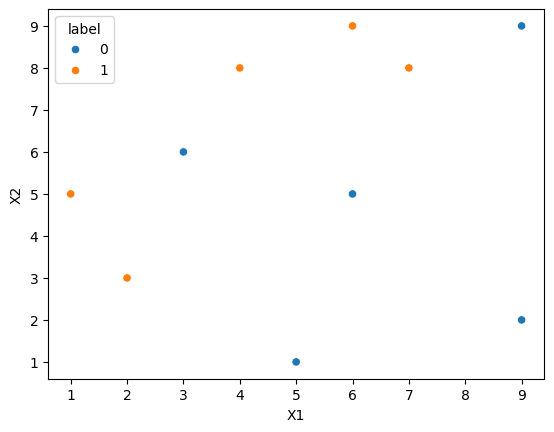

In [5]:
import seaborn as sns
sns.scatterplot(x=df['X1'], y=df['X2'], hue=df['label'])

In [6]:
df['weights'] = 1/df.shape[0]

In [7]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [8]:
from sklearn.tree import DecisionTreeClassifier

In [9]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [10]:
X = df.iloc[:,0:2].values
y = df.iloc[:,2].values

In [11]:
# Step 2 - Train 1st model
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

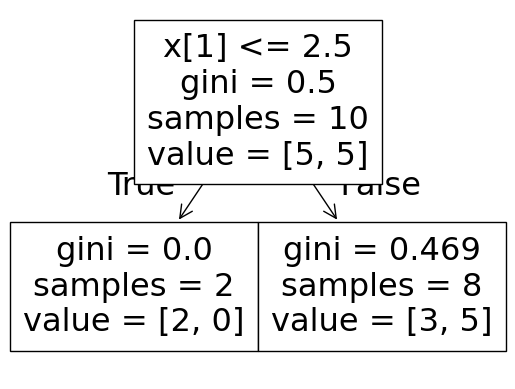

In [12]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

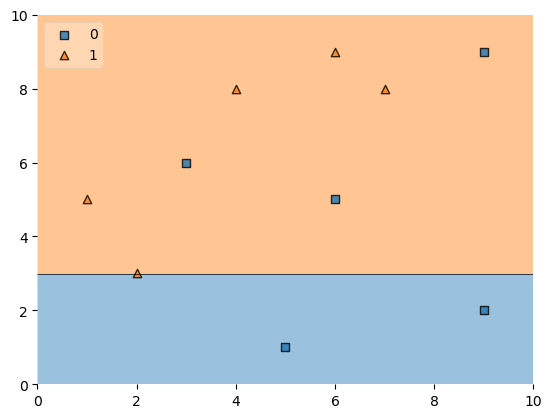

In [13]:
plot_decision_regions(X, y, clf=dt1, legend=2)

In [14]:
df['y_pred'] = dt1.predict(X)

In [15]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


In [16]:
def calculate_model_weight(error):
    return 0.5*np.log((1-error)/(error))

In [17]:
# Step 3 - calculate model weight
# error = sum of weights of misclassifiaction row
alpha1 = calculate_model_weight(0.3)
alpha1

0.42364893019360184

In [18]:
# Step 4 - Update weights where there is misclassification
def update_row_weights(row,alpha=0.423):
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)

In [19]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)

In [20]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [21]:
df['updated_weights'].sum()

0.9165153319682015

In [22]:
df['normalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [23]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [24]:
df['normalized_weights'].sum()

1.0

In [25]:
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])

In [26]:
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']

In [27]:
df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065508,0.071475,0.071475,0.000000
1,2,3,1,0.1,1,0.065508,0.071475,0.142950,0.071475
2,3,6,0,0.1,1,0.152653,0.166559,0.309508,0.142950
3,4,8,1,0.1,1,0.065508,0.071475,0.380983,0.309508
4,5,1,0,0.1,0,0.065508,0.071475,0.452458,0.380983
5,6,9,1,0.1,1,0.065508,0.071475,0.523933,0.452458
6,6,5,0,0.1,1,0.152653,0.166559,0.690492,0.523933
7,7,8,1,0.1,1,0.065508,0.071475,0.761967,0.690492
8,9,9,0,0.1,1,0.152653,0.166559,0.928525,0.761967
9,9,2,0,0.1,0,0.065508,0.071475,1.000000,0.928525


In [28]:
df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.452458,0.523933
6,6,5,0,0.1,1,0.152653,0.523933,0.690492
7,7,8,1,0.1,1,0.065508,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [29]:
def create_new_dataset(df):

    indices = []

    for i in range(df.shape[0]):
        a = np.random.random()
        for index,row in df.iterrows():
            if row['cumsum_upper'] > a and a > row['cumsum_lower']:
                indices.append(index)
    return indices

In [30]:
index_values = create_new_dataset(df)

index_values

[5, 8, 2, 6, 2, 0, 9, 3, 6, 8]

In [31]:
second_df = df.iloc[index_values,[0,1,2,3]]

In [32]:
second_df

,X1,X2,label,weights
5,6,9,1,0.1
8,9,9,0,0.1
2,3,6,0,0.1
6,6,5,0,0.1
2,3,6,0,0.1
0,1,5,1,0.1
9,9,2,0,0.1
3,4,8,1,0.1
6,6,5,0,0.1
8,9,9,0,0.1


In [33]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [34]:
X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

In [35]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

[Text(0.5, 0.75, 'x[0] <= 2.0\ngini = 0.42\nsamples = 10\nvalue = [7, 3]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.346\nsamples = 9\nvalue = [7, 2]'),
 Text(0.625, 0.5, '  False')]

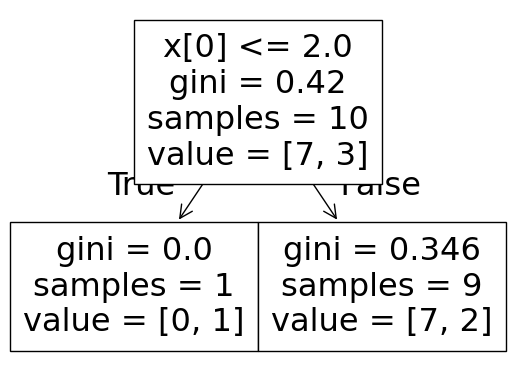

In [36]:
plot_tree(dt2)

<Axes: >

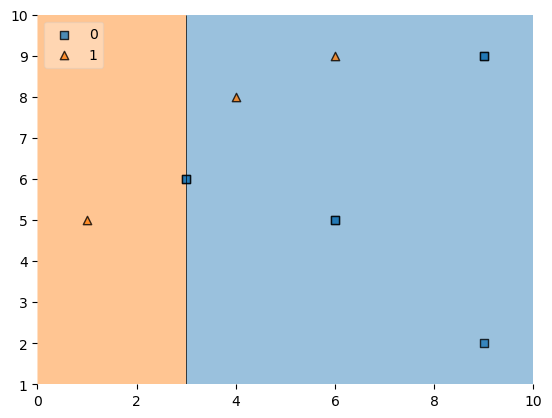

In [37]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [38]:
second_df['y_pred'] = dt2.predict(X)

In [39]:
second_df

,X1,X2,label,weights,y_pred
5,6,9,1,0.1,0
8,9,9,0,0.1,0
2,3,6,0,0.1,0
6,6,5,0,0.1,0
2,3,6,0,0.1,0
0,1,5,1,0.1,1
9,9,2,0,0.1,0
3,4,8,1,0.1,0
6,6,5,0,0.1,0
8,9,9,0,0.1,0


In [40]:
alpha2 = calculate_model_weight(0.2)

In [41]:
alpha2

0.6931471805599453

In [42]:
# Step 4 - Update weights
def update_row_weights(row,alpha=0.693):
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)

In [43]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)

In [44]:
second_df

,X1,X2,label,weights,y_pred,updated_weights
5,6,9,1,0.1,0,0.199971
8,9,9,0,0.1,0,0.050007
2,3,6,0,0.1,0,0.050007
6,6,5,0,0.1,0,0.050007
2,3,6,0,0.1,0,0.050007
0,1,5,1,0.1,1,0.050007
9,9,2,0,0.1,0,0.050007
3,4,8,1,0.1,0,0.199971
6,6,5,0,0.1,0,0.050007
8,9,9,0,0.1,0,0.050007


In [45]:
second_df['updated_weights'].sum()

0.8000000086648471

In [46]:
second_df['normalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [47]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
5,6,9,1,0.1,0,0.199971,0.249963
8,9,9,0,0.1,0,0.050007,0.062509
2,3,6,0,0.1,0,0.050007,0.062509
6,6,5,0,0.1,0,0.050007,0.062509
2,3,6,0,0.1,0,0.050007,0.062509
0,1,5,1,0.1,1,0.050007,0.062509
9,9,2,0,0.1,0,0.050007,0.062509
3,4,8,1,0.1,0,0.199971,0.249963
6,6,5,0,0.1,0,0.050007,0.062509
8,9,9,0,0.1,0,0.050007,0.062509


In [48]:
second_df['normalized_weights'].sum()

0.9999999999999998

In [50]:
second_df['cumsum_upper'] = np.cumsum(second_df['normalized_weights'])

In [51]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['normalized_weights']

In [53]:
second_df[['X1','X2','label','weights','y_pred','normalized_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,normalized_weights,cumsum_lower,cumsum_upper
5,6,9,1,0.1,0,0.249963,0.000000,0.249963
8,9,9,0,0.1,0,0.062509,0.249963,0.312472
2,3,6,0,0.1,0,0.062509,0.312472,0.374982
6,6,5,0,0.1,0,0.062509,0.374982,0.437491
2,3,6,0,0.1,0,0.062509,0.437491,0.500000
0,1,5,1,0.1,1,0.062509,0.500000,0.562509
9,9,2,0,0.1,0,0.062509,0.562509,0.625018
3,4,8,1,0.1,0,0.249963,0.625018,0.874982
6,6,5,0,0.1,0,0.062509,0.874982,0.937491
8,9,9,0,0.1,0,0.062509,0.937491,1.000000


In [54]:
index_values = create_new_dataset(second_df)

In [55]:
third_df = second_df.iloc[index_values,[0,1,2,3]]

In [56]:

third_df
     

,X1,X2,label,weights
0,1,5,1,0.1
8,9,9,0,0.1
0,1,5,1,0.1
9,9,2,0,0.1
0,1,5,1,0.1
6,6,5,0,0.1
2,3,6,0,0.1
9,9,2,0,0.1
6,6,5,0,0.1
0,1,5,1,0.1


In [57]:
dt3 = DecisionTreeClassifier(max_depth=1)

X = second_df.iloc[:,0:2].values
y = second_df.iloc[:,2].values

dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

<Axes: >

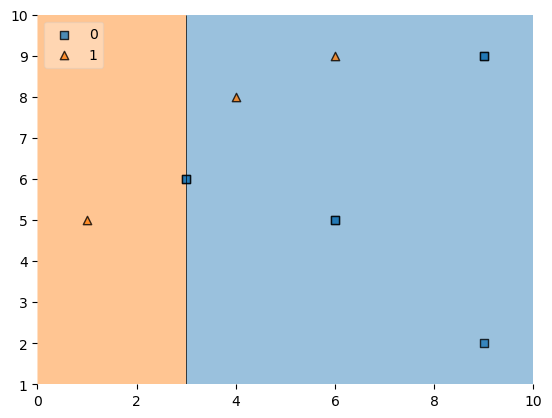

In [58]:
plot_decision_regions(X, y, clf=dt3, legend=2)

In [59]:
third_df['y_pred'] = dt3.predict(X)

In [60]:
third_df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,0
8,9,9,0,0.1,0
0,1,5,1,0.1,0
9,9,2,0,0.1,0
0,1,5,1,0.1,0
6,6,5,0,0.1,1
2,3,6,0,0.1,0
9,9,2,0,0.1,0
6,6,5,0,0.1,0
0,1,5,1,0.1,0


In [63]:
alpha3 = calculate_model_weight(0.6)
alpha3

-0.20273255405408214

In [64]:
print(alpha1,alpha2,alpha3)

0.42364893019360184 0.6931471805599453 -0.20273255405408214


# Prediction

In [65]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1], dtype=int64)

In [66]:
dt2.predict(query)

array([1], dtype=int64)

In [67]:
dt3.predict(query)

array([1], dtype=int64)

In [68]:
alpha1*1 + alpha2*(1) + alpha3*(1)

0.914063556699465

In [69]:
np.sign(0.914)

1.0

In [70]:
query = np.array([9,9]).reshape(1,2)
dt1.predict(query)

array([1], dtype=int64)

In [71]:
dt2.predict(query)

array([0], dtype=int64)

In [72]:
dt3.predict(query)

array([0], dtype=int64)

In [73]:
alpha1*(1) + alpha2*(-1) + alpha3*(-1)

-0.06676569631226131

In [75]:
np.sign(-0.066)

-1.0